# Park equal-area Polyconic Projection
# Heart-shaped Polyconic Projection with Preserved Meridian Distances

bad_cells: 0


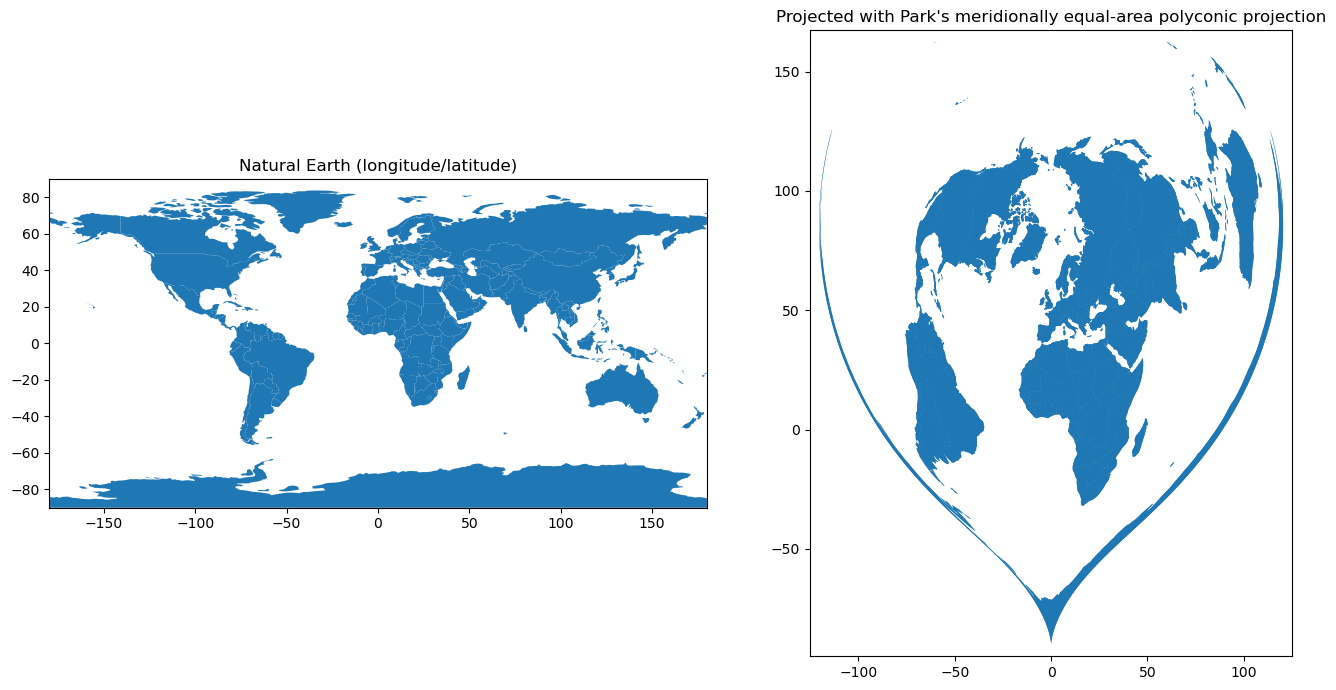

Saved: /mnt/data/park_polyconic_world_map1.png
Saved: /mnt/data/park_polyconic_world_map1.pdf


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString, GeometryCollection
from shapely.ops import transform

def densify_coords(coords, max_step=0.25):
    new = []
    coords = list(coords)

    for (x0, y0), (x1, y1) in zip(coords[:-1], coords[1:]):
        new.append((x0, y0))
        dist = max(abs(x1 - x0), abs(y1 - y0))
        n = max(1, int(np.ceil(dist / max_step)))
        for k in range(1, n):
            t = k / n
            new.append((x0 + t * (x1 - x0), y0 + t * (y1 - y0)))

    new.append(coords[-1])
    return new

def densify_polygon(poly, max_step=0.25):
    exterior = densify_coords(poly.exterior.coords, max_step)
    interiors = [densify_coords(ring.coords, max_step) for ring in poly.interiors]
    return Polygon(exterior, interiors)

def densify_geom(geom, max_step=0.25):
    if geom.geom_type == "Polygon":
        return densify_polygon(geom, max_step)
    elif geom.geom_type == "MultiPolygon":
        return MultiPolygon([densify_polygon(g, max_step) for g in geom.geoms])
    else:
        return geom



# --- Projection grid from the user's code ---
def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

# --- Equal-area projection grid, graticule-cell based ---

def signed_tri_area(A, B, C):
    return 0.5 * np.cross(B - A, C - A)

def signed_quad_area(A, B, D, C):
    pts = np.array([A, B, D, C])
    x = pts[:, 0]
    y = pts[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - y * np.roll(x, -1))

def cell_area_sphere_scaled(lat_north, lat_south, dlon_deg=0.5):
    """
    Area of lon-lat cell on unit sphere, scaled to the projection plane.
    The scale is chosen so that the 89°–90° polar cap edge has radius 1.
    """
    cap_factor = 1.0 - np.sin(np.deg2rad(89.0))
    K = 1.0 / (2.0 * cap_factor)

    dlon = np.deg2rad(dlon_deg)
    return K * dlon * (
        np.sin(np.deg2rad(lat_north)) - np.sin(np.deg2rad(lat_south))
    )

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

# North pole row
Y[0, :] = 90.0
X[0, :] = 0.0

# Central meridian
for a in range(0, 181):
    X[a, 0] = 0.0
    Y[a, 0] = 90.0 - a

# First row below the pole: unit circular arc around the north pole.
# lon = A / 2 degrees, A = 0..360.
for A in range(0, 361):
    lon = A / 2.0
    theta = np.deg2rad(lon)
    X[1, A] = np.sin(theta)
    Y[1, A] = 90.0 - np.cos(theta)

# Fill from high northern latitudes downward,
# and from central meridian eastward to 180°.
bad_cells = []

for a in range(1, 180):
    lat_north = 90.0 - a
    lat_south = 90.0 - (a + 1)

    target_area = cell_area_sphere_scaled(
        lat_north, lat_south, dlon_deg=0.5
    )

    # In x-right, y-up coordinates, the polygon A-B-D-C is clockwise.
    target_signed_area = -target_area

    for b in range(0, 360):
        A = np.array([X[a, b],     Y[a, b]])
        B = np.array([X[a, b + 1], Y[a, b + 1]])
        C = np.array([X[a + 1, b], Y[a + 1, b]])

        v = C - B
        L = np.hypot(v[0], v[1])

        if L == 0:
            bad_cells.append((a, b, "zero diagonal"))
            X[a + 1, b + 1] = X[a + 1, b]
            Y[a + 1, b + 1] = Y[a + 1, b]
            continue

        # Area of triangle A-B-C
        area_ABC = signed_tri_area(A, B, C)

        # Need:
        # area(A,B,D,C) = area_ABC + 0.5 * cross(D-B, C-B)
        # Therefore:
        desired_cross = 2.0 * (target_signed_area - area_ABC)

        # Let D-B be a unit vector obtained by rotating v/L.
        # cross(R_theta(v/L), v) = -L sin(theta)
        sin_theta = -desired_cross / L

        if abs(sin_theta) > 1.0:
            bad_cells.append((a, b, sin_theta))
            sin_theta = np.clip(sin_theta, -1.0, 1.0)

        cos_theta = np.sqrt(max(0.0, 1.0 - sin_theta**2))

        dx, dy = v

        ux = (cos_theta * dx - sin_theta * dy) / L
        uy = (sin_theta * dx + cos_theta * dy) / L

        D = B + np.array([ux, uy])

        X[a + 1, b + 1] = D[0]
        Y[a + 1, b + 1] = D[1]

Xp = X[:, :361]
Yp = Y[:, :361]

print("bad_cells:", len(bad_cells))
if bad_cells:
    print("first few:", bad_cells[:10])

# --- Bilinear interpolation on the precomputed grid ---
def project_point(lon, lat):
    # Clamp to valid input domain
    lon = float(np.clip(lon, -180.0, 180.0))
    lat = float(np.clip(lat, -90.0, 90.0))

    # Grid coordinates:
    # rows: 90 -> -90 by 1 degree
    # cols: 0 -> 180 by 0.5 degree, stored as 0..360
    row = 90.0 - lat
    col = abs(lon) * 2.0

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )
    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon < 0:
        x = -x

    return x, y

# Shapely transform helper
def proj_transform(x, y, z=None):
    # shapely sends arrays
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    out_x = np.empty_like(x)
    out_y = np.empty_like(y)

    for i in range(len(x)):
        px, py = project_point(x[i], y[i])
        out_x[i] = px
        out_y[i] = py

    if z is None:
        return out_x, out_y
    return out_x, out_y, z

# --- Load a local Natural Earth low-res world shapefile ---
#shp_path = "/opt/pyvenv/lib/python3.13/site-packages/pyogrio/tests/fixtures/naturalearth_lowres/naturalearth_lowres.shp"
#world = gpd.read_file(shp_path)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
# Project geometries



world2 = world.copy()

antarctica_mask = world2["ADMIN"].eq("Antarctica") | world2["NAME"].eq("Antarctica")

world2.loc[antarctica_mask, "geometry"] = world2.loc[
    antarctica_mask, "geometry"
].apply(lambda g: densify_geom(g, max_step=0.25))

projected_geoms = world2.geometry.apply(lambda geom: transform(proj_transform, geom))





# --- Make figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: original lon/lat
world.plot(ax=axes[0], linewidth=0.5)
axes[0].set_title("Natural Earth (longitude/latitude)")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-90, 90)

# Right: projected
gpd.GeoSeries(projected_geoms, crs=None).plot(ax=axes[1], linewidth=0.5)
axes[1].set_title("Projected with Park's meridionally equal-area polyconic projection")
axes[1].set_aspect("equal", adjustable="box")

proj_series = gpd.GeoSeries(projected_geoms, crs=None)
proj_series.plot(ax=axes[1], linewidth=0.5)

minx, miny, maxx, maxy = proj_series.total_bounds
pad_x = (maxx - minx) * 0.02
pad_y = (maxy - miny) * 0.02
axes[1].set_xlim(minx - pad_x, maxx + pad_x)
axes[1].set_ylim(miny - pad_y, maxy + pad_y)


for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()

png_path = "/mnt/data/park_polyconic_world_map1.png"
pdf_path = "/mnt/data/park_polyconic_world_map1.pdf"
fig.savefig(png_path, dpi=220, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")


bad_cells: 0


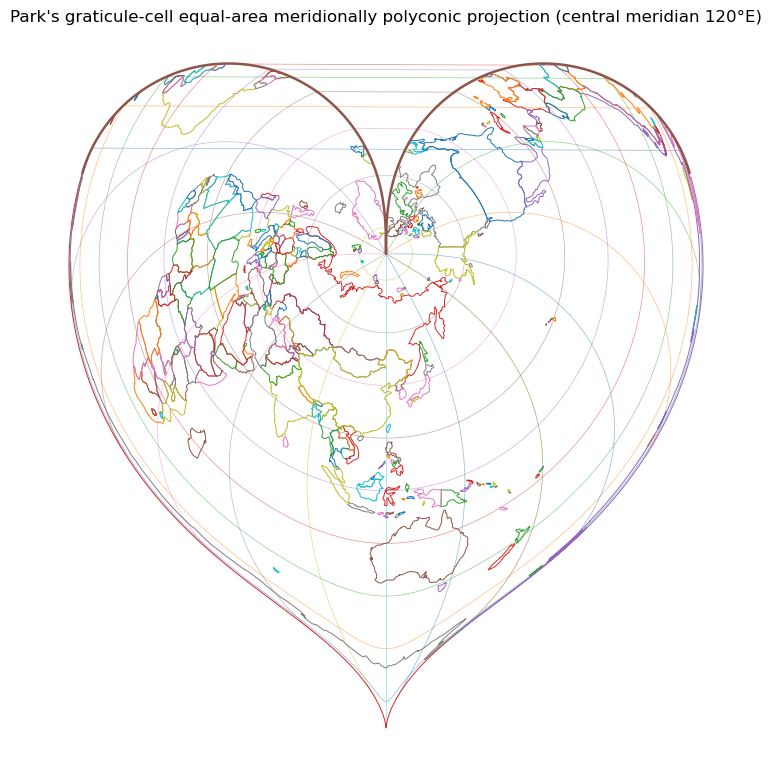

Saved: /mnt/data/park_equal_area_polyconic_120E_boundary.png
Saved: /mnt/data/park_equal_area_polyconic_120E_boundary.pdf


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon

# -----------------------------
# 1) Build equal-area projection grid
# -----------------------------
def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

def signed_tri_area(A, B, C):
    return 0.5 * np.cross(B - A, C - A)

def cell_area_sphere_scaled(lat_north, lat_south, dlon_deg=0.5):
    cap_factor = 1.0 - np.sin(np.deg2rad(89.0))
    K = 1.0 / (2.0 * cap_factor)

    dlon = np.deg2rad(dlon_deg)
    return K * dlon * (
        np.sin(np.deg2rad(lat_north)) - np.sin(np.deg2rad(lat_south))
    )

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

# North pole
X[0, :] = 0.0
Y[0, :] = 90.0

# Central meridian
for a in range(181):
    X[a, 0] = 0.0
    Y[a, 0] = 90.0 - a

# First row below pole
for A in range(361):
    lon = A / 2.0
    theta = np.deg2rad(lon)
    X[1, A] = np.sin(theta)
    Y[1, A] = 90.0 - np.cos(theta)

bad_cells = []

for a in range(1, 180):
    lat_north = 90.0 - a
    lat_south = 90.0 - (a + 1)

    target_area = cell_area_sphere_scaled(
        lat_north, lat_south, dlon_deg=0.5
    )
    target_signed_area = -target_area

    for b in range(360):
        A = np.array([X[a, b],     Y[a, b]])
        B = np.array([X[a, b + 1], Y[a, b + 1]])
        C = np.array([X[a + 1, b], Y[a + 1, b]])

        v = C - B
        L = np.hypot(v[0], v[1])

        if L == 0:
            bad_cells.append((a, b, "zero diagonal"))
            X[a + 1, b + 1] = X[a + 1, b]
            Y[a + 1, b + 1] = Y[a + 1, b]
            continue

        area_ABC = signed_tri_area(A, B, C)
        desired_cross = 2.0 * (target_signed_area - area_ABC)

        sin_theta = -desired_cross / L

        if abs(sin_theta) > 1.0:
            bad_cells.append((a, b, sin_theta))
            sin_theta = np.clip(sin_theta, -1.0, 1.0)

        cos_theta = np.sqrt(max(0.0, 1.0 - sin_theta**2))

        dx, dy = v
        ux = (cos_theta * dx - sin_theta * dy) / L
        uy = (sin_theta * dx + cos_theta * dy) / L

        D = B + np.array([ux, uy])

        X[a + 1, b + 1] = D[0]
        Y[a + 1, b + 1] = D[1]

Xp = X[:, :361]
Yp = Y[:, :361]

print("bad_cells:", len(bad_cells))
if bad_cells:
    print("first few:", bad_cells[:10])

# -----------------------------
# 2) Projection with movable central meridian
# -----------------------------
CENTRAL_MERIDIAN = 120.0

def wrap_lon_relative(lon, lon0=CENTRAL_MERIDIAN):
    return ((lon - lon0 + 180.0) % 360.0) - 180.0

def project_point(lon, lat, lon0=CENTRAL_MERIDIAN):
    lon_rel = wrap_lon_relative(lon, lon0)
    lat = float(np.clip(lat, -90.0, 90.0))

    row = 90.0 - lat
    col = abs(lon_rel) * 2.0

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )
    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon_rel < 0:
        x = -x

    return x, y

# -----------------------------
# 3) Safe line rendering split at seam
# -----------------------------
def densify_segment(p0, p1, max_step_deg=1.0):
    lon0, lat0 = p0
    lon1, lat1 = p1

    n = max(
        1,
        int(np.ceil(max(abs(lon1 - lon0), abs(lat1 - lat0)) / max_step_deg))
    )

    pts = []
    for k in range(n):
        t = k / n
        pts.append((
            lon0 + t * (lon1 - lon0),
            lat0 + t * (lat1 - lat0)
        ))
    return pts

def ring_to_projected_segments(coords, lon0=CENTRAL_MERIDIAN, max_step_deg=1.0):
    coords = list(coords)
    if len(coords) < 2:
        return []

    dense = []
    for i in range(len(coords) - 1):
        dense.extend(
            densify_segment(coords[i], coords[i + 1], max_step_deg=max_step_deg)
        )
    dense.append(coords[-1])

    segments = []
    current = []
    prev_rel = None

    for lon, lat in dense:
        rel = wrap_lon_relative(lon, lon0)

        if prev_rel is not None and abs(rel - prev_rel) > 180:
            if len(current) >= 2:
                segments.append(current)
            current = []

        x, y = project_point(lon, lat, lon0)
        current.append((x, y))
        prev_rel = rel

    if len(current) >= 2:
        segments.append(current)

    return segments

def extract_segments_from_geom(geom, lon0=CENTRAL_MERIDIAN):
    segments = []

    if isinstance(geom, Polygon):
        segments.extend(
            ring_to_projected_segments(geom.exterior.coords, lon0=lon0)
        )
        for interior in geom.interiors:
            segments.extend(
                ring_to_projected_segments(interior.coords, lon0=lon0)
            )

    elif isinstance(geom, MultiPolygon):
        for poly in geom.geoms:
            segments.extend(extract_segments_from_geom(poly, lon0=lon0))

    return segments

# -----------------------------
# 4) Load Natural Earth
# -----------------------------
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

all_segments = []
for geom in world.geometry:
    all_segments.extend(extract_segments_from_geom(geom, lon0=CENTRAL_MERIDIAN))

# -----------------------------
# 5) Boundary and graticules
# -----------------------------
boundary_x = np.concatenate([-Xp[::-1, 360], Xp[:, 360]])
boundary_y = np.concatenate([Yp[::-1, 360], Yp[:, 360]])

graticule_parallels = []
for lat in range(-80, 81, 20):
    lons = np.linspace(-180, 180, 721)
    pts = [project_point(lon, lat, CENTRAL_MERIDIAN) for lon in lons]
    graticule_parallels.append(np.array(pts))

graticule_meridians = []
for lon in range(-180, 181, 30):
    lats = np.linspace(-90, 90, 721)
    pts = [project_point(lon, lat, CENTRAL_MERIDIAN) for lat in lats]
    graticule_meridians.append(np.array(pts))

# -----------------------------
# 6) Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 10))

for arr in graticule_parallels:
    ax.plot(arr[:, 0], arr[:, 1], linewidth=0.5, alpha=0.5)

for arr in graticule_meridians:
    ax.plot(arr[:, 0], arr[:, 1], linewidth=0.5, alpha=0.5)

for seg in all_segments:
    arr = np.asarray(seg)
    ax.plot(arr[:, 0], arr[:, 1], linewidth=0.7)

ax.plot(boundary_x, boundary_y, linewidth=1.8)

ax.set_aspect("equal", adjustable="box")
ax.set_title(
    "Park's graticule-cell equal-area meridionally polyconic projection "
    "(central meridian 120°E)"
)
ax.set_axis_off()

png_path = "/mnt/data/park_equal_area_polyconic_120E_boundary.png"
pdf_path = "/mnt/data/park_equal_area_polyconic_120E_boundary.pdf"

fig.savefig(png_path, dpi=240, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

bad_cells: 0


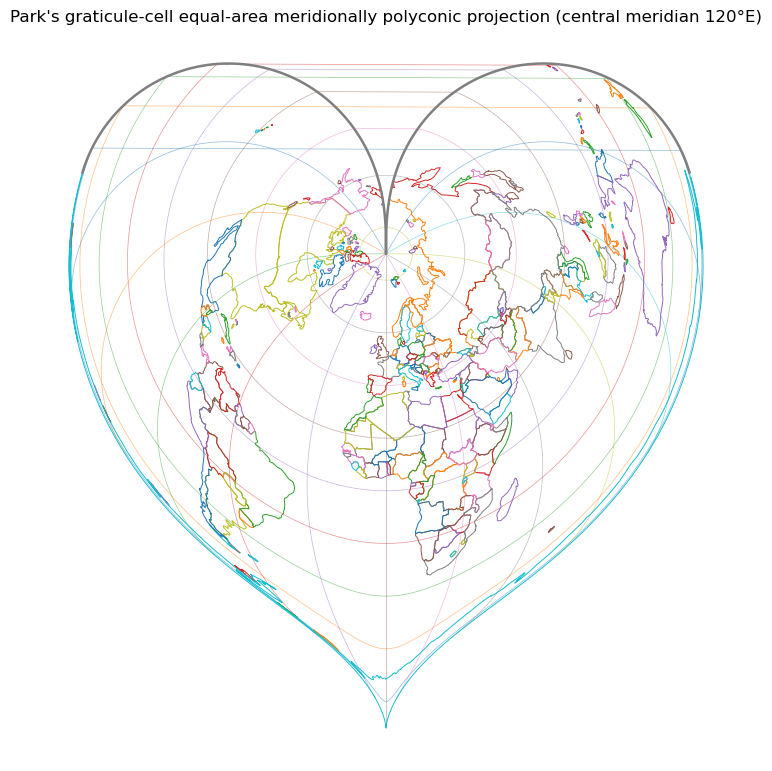

Saved: /mnt/data/park_equal_area_polyconic_0E_boundary.png
Saved: /mnt/data/park_equal_area_polyconic_0E_boundary.pdf


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon

# -----------------------------
# 1) Build  projection grid
# -----------------------------
def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

def signed_tri_area(A, B, C):
    return 0.5 * np.cross(B - A, C - A)

def cell_area_sphere_scaled(lat_north, lat_south, dlon_deg=0.5):
    cap_factor = 1.0 - np.sin(np.deg2rad(89.0))
    K = 1.0 / (2.0 * cap_factor)

    dlon = np.deg2rad(dlon_deg)
    return K * dlon * (
        np.sin(np.deg2rad(lat_north)) - np.sin(np.deg2rad(lat_south))
    )

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

# North pole
X[0, :] = 0.0
Y[0, :] = 90.0

# Central meridian
for a in range(181):
    X[a, 0] = 0.0
    Y[a, 0] = 90.0 - a

# First row below pole
for A in range(361):
    lon = A / 2.0
    theta = np.deg2rad(lon)
    X[1, A] = np.sin(theta)
    Y[1, A] = 90.0 - np.cos(theta)

bad_cells = []

for a in range(1, 180):
    lat_north = 90.0 - a
    lat_south = 90.0 - (a + 1)

    target_area = cell_area_sphere_scaled(
        lat_north, lat_south, dlon_deg=0.5
    )
    target_signed_area = -target_area

    for b in range(360):
        A = np.array([X[a, b],     Y[a, b]])
        B = np.array([X[a, b + 1], Y[a, b + 1]])
        C = np.array([X[a + 1, b], Y[a + 1, b]])

        v = C - B
        L = np.hypot(v[0], v[1])

        if L == 0:
            bad_cells.append((a, b, "zero diagonal"))
            X[a + 1, b + 1] = X[a + 1, b]
            Y[a + 1, b + 1] = Y[a + 1, b]
            continue

        area_ABC = signed_tri_area(A, B, C)
        desired_cross = 2.0 * (target_signed_area - area_ABC)

        sin_theta = -desired_cross / L

        if abs(sin_theta) > 1.0:
            bad_cells.append((a, b, sin_theta))
            sin_theta = np.clip(sin_theta, -1.0, 1.0)

        cos_theta = np.sqrt(max(0.0, 1.0 - sin_theta**2))

        dx, dy = v
        ux = (cos_theta * dx - sin_theta * dy) / L
        uy = (sin_theta * dx + cos_theta * dy) / L

        D = B + np.array([ux, uy])

        X[a + 1, b + 1] = D[0]
        Y[a + 1, b + 1] = D[1]

Xp = X[:, :361]
Yp = Y[:, :361]

print("bad_cells:", len(bad_cells))
if bad_cells:
    print("first few:", bad_cells[:10])

# -----------------------------
# 2) Projection with movable central meridian
# -----------------------------
CENTRAL_MERIDIAN = 0

def wrap_lon_relative(lon, lon0=CENTRAL_MERIDIAN):
    return ((lon - lon0 + 180.0) % 360.0) - 180.0

def project_point(lon, lat, lon0=CENTRAL_MERIDIAN):
    lon_rel = wrap_lon_relative(lon, lon0)
    lat = float(np.clip(lat, -90.0, 90.0))

    row = 90.0 - lat
    col = abs(lon_rel) * 2.0

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )
    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon_rel < 0:
        x = -x

    return x, y

# -----------------------------
# 3) Safe line rendering split at seam
# -----------------------------
def densify_segment(p0, p1, max_step_deg=1.0):
    lon0, lat0 = p0
    lon1, lat1 = p1

    n = max(
        1,
        int(np.ceil(max(abs(lon1 - lon0), abs(lat1 - lat0)) / max_step_deg))
    )

    pts = []
    for k in range(n):
        t = k / n
        pts.append((
            lon0 + t * (lon1 - lon0),
            lat0 + t * (lat1 - lat0)
        ))
    return pts

def ring_to_projected_segments(coords, lon0=CENTRAL_MERIDIAN, max_step_deg=1.0):
    coords = list(coords)
    if len(coords) < 2:
        return []

    dense = []
    for i in range(len(coords) - 1):
        dense.extend(
            densify_segment(coords[i], coords[i + 1], max_step_deg=max_step_deg)
        )
    dense.append(coords[-1])

    segments = []
    current = []
    prev_rel = None

    for lon, lat in dense:
        rel = wrap_lon_relative(lon, lon0)

        if prev_rel is not None and abs(rel - prev_rel) > 180:
            if len(current) >= 2:
                segments.append(current)
            current = []

        x, y = project_point(lon, lat, lon0)
        current.append((x, y))
        prev_rel = rel

    if len(current) >= 2:
        segments.append(current)

    return segments

def extract_segments_from_geom(geom, lon0=CENTRAL_MERIDIAN):
    segments = []

    if isinstance(geom, Polygon):
        segments.extend(
            ring_to_projected_segments(geom.exterior.coords, lon0=lon0)
        )
        for interior in geom.interiors:
            segments.extend(
                ring_to_projected_segments(interior.coords, lon0=lon0)
            )

    elif isinstance(geom, MultiPolygon):
        for poly in geom.geoms:
            segments.extend(extract_segments_from_geom(poly, lon0=lon0))

    return segments

# -----------------------------
# 4) Load Natural Earth
# -----------------------------
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

all_segments = []
for geom in world.geometry:
    all_segments.extend(extract_segments_from_geom(geom, lon0=CENTRAL_MERIDIAN))

# -----------------------------
# 5) Boundary and graticules
# -----------------------------
boundary_x = np.concatenate([-Xp[::-1, 360], Xp[:, 360]])
boundary_y = np.concatenate([Yp[::-1, 360], Yp[:, 360]])

graticule_parallels = []
for lat in range(-80, 81, 20):
    lons = np.linspace(-180, 180, 721)
    pts = [project_point(lon, lat, CENTRAL_MERIDIAN) for lon in lons]
    graticule_parallels.append(np.array(pts))

graticule_meridians = []
for lon in range(-180, 181, 30):
    lats = np.linspace(-90, 90, 721)
    pts = [project_point(lon, lat, CENTRAL_MERIDIAN) for lat in lats]
    graticule_meridians.append(np.array(pts))

# -----------------------------
# 6) Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 10))

for arr in graticule_parallels:
    ax.plot(arr[:, 0], arr[:, 1], linewidth=0.5, alpha=0.5)

for arr in graticule_meridians:
    ax.plot(arr[:, 0], arr[:, 1], linewidth=0.5, alpha=0.5)

for seg in all_segments:
    arr = np.asarray(seg)
    ax.plot(arr[:, 0], arr[:, 1], linewidth=0.7)

ax.plot(boundary_x, boundary_y, linewidth=1.8)

ax.set_aspect("equal", adjustable="box")
ax.set_title(
    "Park's graticule-cell equal-area meridionally polyconic projection "
    "(central meridian 120°E)"
)
ax.set_axis_off()

png_path = "/mnt/data/park_equal_area_polyconic_0E_boundary.png"
pdf_path = "/mnt/data/park_equal_area_polyconic_0E_boundary.pdf"

fig.savefig(png_path, dpi=240, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

bad_cells: 0


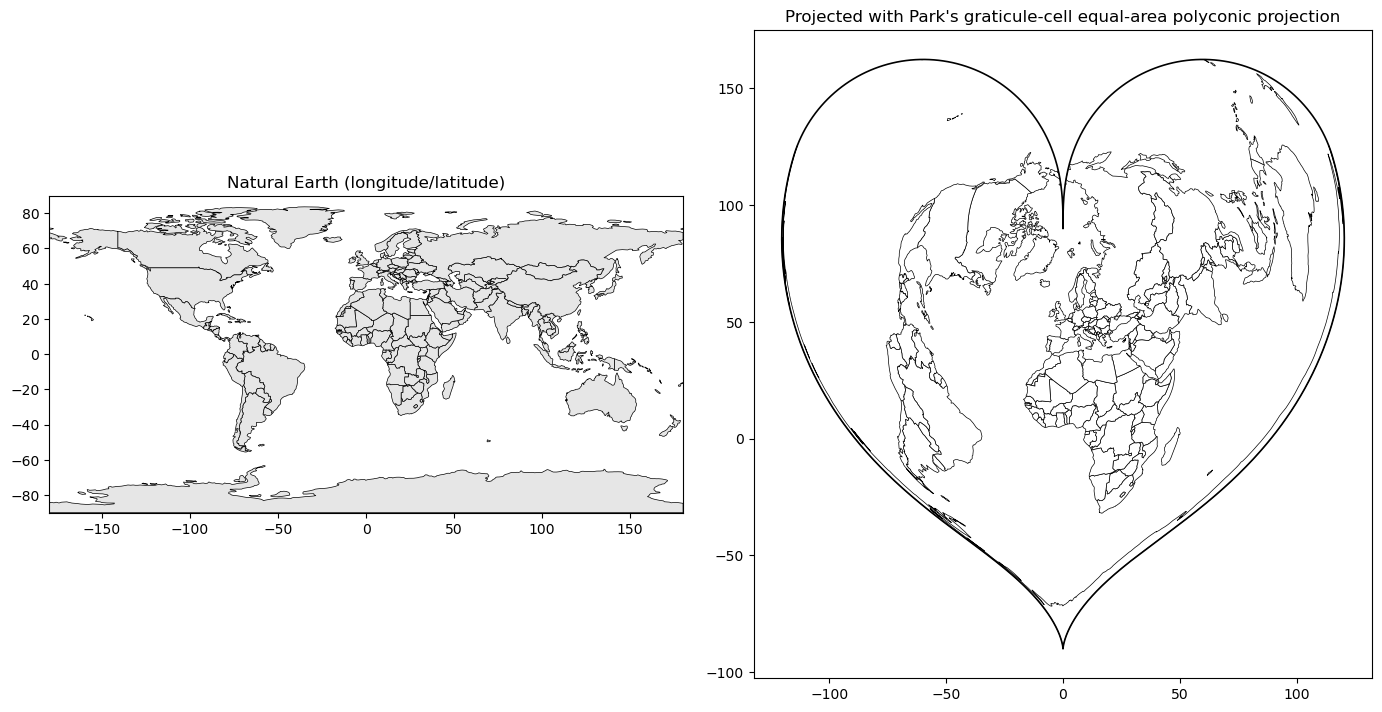

Saved: /mnt/data/park_equal_area_polyconic_world_map3.png
Saved: /mnt/data/park_equal_area_polyconic_world_map3.pdf


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.ops import transform

# -----------------------------
# 1) Equal-area projection grid
# -----------------------------
def signed_tri_area(A, B, C):
    return 0.5 * np.cross(B - A, C - A)

def cell_area_sphere_scaled(lat_north, lat_south, dlon_deg=0.5):
    """
    Graticule-cell area on the sphere, scaled to the projection plane.
    """
    cap_factor = 1.0 - np.sin(np.deg2rad(89.0))
    K = 1.0 / (2.0 * cap_factor)

    dlon = np.deg2rad(dlon_deg)
    return K * dlon * (
        np.sin(np.deg2rad(lat_north)) - np.sin(np.deg2rad(lat_south))
    )

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

# North pole
X[0, :] = 0.0
Y[0, :] = 90.0

# Central meridian
for A in range(181):
    X[A, 0] = 0.0
    Y[A, 0] = 90.0 - A

# First row below the pole
for A in range(361):
    lon = A / 2.0
    theta = np.deg2rad(lon)
    X[1, A] = np.sin(theta)
    Y[1, A] = 90.0 - np.cos(theta)

bad_cells = []

for a in range(1, 180):
    lat_north = 90.0 - a
    lat_south = 90.0 - (a + 1)

    target_area = cell_area_sphere_scaled(
        lat_north, lat_south, dlon_deg=0.5
    )

    # A-B-D-C is clockwise in x-right, y-up coordinates.
    target_signed_area = -target_area

    for b in range(360):
        A = np.array([X[a, b],     Y[a, b]])
        B = np.array([X[a, b + 1], Y[a, b + 1]])
        C = np.array([X[a + 1, b], Y[a + 1, b]])

        v = C - B
        L = np.hypot(v[0], v[1])

        if L == 0:
            bad_cells.append((a, b, "zero diagonal"))
            X[a + 1, b + 1] = X[a + 1, b]
            Y[a + 1, b + 1] = Y[a + 1, b]
            continue

        area_ABC = signed_tri_area(A, B, C)
        desired_cross = 2.0 * (target_signed_area - area_ABC)

        sin_theta = -desired_cross / L

        if abs(sin_theta) > 1.0:
            bad_cells.append((a, b, sin_theta))
            sin_theta = np.clip(sin_theta, -1.0, 1.0)

        cos_theta = np.sqrt(max(0.0, 1.0 - sin_theta**2))

        dx, dy = v

        ux = (cos_theta * dx - sin_theta * dy) / L
        uy = (sin_theta * dx + cos_theta * dy) / L

        D = B + np.array([ux, uy])

        X[a + 1, b + 1] = D[0]
        Y[a + 1, b + 1] = D[1]

Xp = X[:, :361]
Yp = Y[:, :361]

print("bad_cells:", len(bad_cells))
if bad_cells:
    print("first few:", bad_cells[:10])

# -----------------------------
# 2) Bilinear interpolation
# -----------------------------
def project_point(lon, lat):
    lon = float(np.clip(lon, -180.0, 180.0))
    lat = float(np.clip(lat, -90.0, 90.0))

    row = 90.0 - lat
    col = abs(lon) * 2.0

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )
    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon < 0:
        x = -x

    return x, y

def proj_transform(x, y, z=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    out_x = np.empty_like(x)
    out_y = np.empty_like(y)

    for i in range(len(x)):
        px, py = project_point(x[i], y[i])
        out_x[i] = px
        out_y[i] = py

    if z is None:
        return out_x, out_y
    return out_x, out_y, z

# -----------------------------
# 3) Densify helper
# -----------------------------
def densify_geom(geom, max_segment_length=0.25):
    return geom.segmentize(max_segment_length)

# -----------------------------
# 4) Projection boundary
# -----------------------------
def projection_boundary(n=2000):
    lats_right = np.linspace(90, -90, n)
    right = np.array([project_point(180, lat) for lat in lats_right])

    lons_bottom = np.linspace(180, -180, 2 * n)
    bottom = np.array([project_point(lon, -90) for lon in lons_bottom])

    lats_left = np.linspace(-90, 90, n)
    left = np.array([project_point(-180, lat) for lat in lats_left])

    boundary = np.vstack([right, bottom[1:], left[1:]])
    return boundary[:, 0], boundary[:, 1]

# -----------------------------
# 5) Load world data
# -----------------------------
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

antarctica = world[world["NAME"] == "Antarctica"].copy()
others = world[world["NAME"] != "Antarctica"].copy()

others_proj = others.geometry.apply(lambda geom: transform(proj_transform, geom))

antarctica_dense = antarctica.geometry.apply(
    lambda geom: densify_geom(geom, max_segment_length=0.15)
)
antarctica_proj = antarctica_dense.apply(lambda geom: transform(proj_transform, geom))

bx, by = projection_boundary()

# -----------------------------
# 6) Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

world.plot(
    ax=axes[0],
    linewidth=0.5,
    facecolor="0.9",
    edgecolor="black"
)
axes[0].set_title("Natural Earth (longitude/latitude)")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-90, 90)

gpd.GeoSeries(others_proj, crs=None).plot(
    ax=axes[1],
    linewidth=0.5,
    facecolor="white",
    edgecolor="black"
)

gpd.GeoSeries(antarctica_proj, crs=None).plot(
    ax=axes[1],
    linewidth=0.5,
    facecolor="white",
    edgecolor="black",
    zorder=3
)

axes[1].plot(bx, by, linewidth=1.2, color="black", zorder=5)

axes[1].set_title(
    "Projected with Park's graticule-cell equal-area polyconic projection"
)
axes[1].set_aspect("equal", adjustable="box")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()

png_path = "/mnt/data/park_equal_area_polyconic_world_map3.png"
pdf_path = "/mnt/data/park_equal_area_polyconic_world_map3.pdf"

fig.savefig(png_path, dpi=220, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

bad_cells: 0


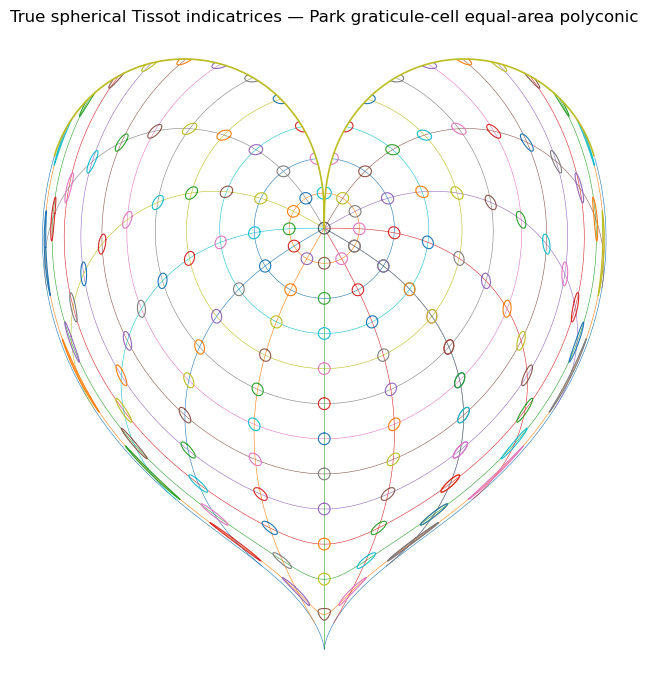

/mnt/data/park_equal_area_polyconic_true_tissot.png
/mnt/data/park_equal_area_polyconic_true_tissot.pdf


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Build equal-area projection grid
# -----------------------------
def signed_tri_area(A, B, C):
    return 0.5 * np.cross(B - A, C - A)

def cell_area_sphere_scaled(lat_north, lat_south, dlon_deg=0.5):
    cap_factor = 1.0 - np.sin(np.deg2rad(89.0))
    K = 1.0 / (2.0 * cap_factor)

    dlon = np.deg2rad(dlon_deg)
    return K * dlon * (
        np.sin(np.deg2rad(lat_north)) - np.sin(np.deg2rad(lat_south))
    )

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

# North pole
X[0, :] = 0.0
Y[0, :] = 90.0

# Central meridian
for A in range(181):
    X[A, 0] = 0.0
    Y[A, 0] = 90.0 - A

# First row below the pole
for A in range(361):
    lon = A / 2.0
    theta = np.deg2rad(lon)
    X[1, A] = np.sin(theta)
    Y[1, A] = 90.0 - np.cos(theta)

bad_cells = []

for a in range(1, 180):
    lat_north = 90.0 - a
    lat_south = 90.0 - (a + 1)

    target_area = cell_area_sphere_scaled(
        lat_north, lat_south, dlon_deg=0.5
    )

    target_signed_area = -target_area

    for b in range(360):
        A = np.array([X[a, b],     Y[a, b]])
        B = np.array([X[a, b + 1], Y[a, b + 1]])
        C = np.array([X[a + 1, b], Y[a + 1, b]])

        v = C - B
        L = np.hypot(v[0], v[1])

        if L == 0:
            bad_cells.append((a, b, "zero diagonal"))
            X[a + 1, b + 1] = X[a + 1, b]
            Y[a + 1, b + 1] = Y[a + 1, b]
            continue

        area_ABC = signed_tri_area(A, B, C)
        desired_cross = 2.0 * (target_signed_area - area_ABC)

        sin_theta = -desired_cross / L

        if abs(sin_theta) > 1.0:
            bad_cells.append((a, b, sin_theta))
            sin_theta = np.clip(sin_theta, -1.0, 1.0)

        cos_theta = np.sqrt(max(0.0, 1.0 - sin_theta**2))

        dx, dy = v

        ux = (cos_theta * dx - sin_theta * dy) / L
        uy = (sin_theta * dx + cos_theta * dy) / L

        D = B + np.array([ux, uy])

        X[a + 1, b + 1] = D[0]
        Y[a + 1, b + 1] = D[1]

Xp = X[:, :361]
Yp = Y[:, :361]

print("bad_cells:", len(bad_cells))
if bad_cells:
    print("first few:", bad_cells[:10])

CENTRAL_MERIDIAN = 120.0

def wrap_lon_relative(lon, lon0=CENTRAL_MERIDIAN):
    return ((lon - lon0 + 180.0) % 360.0) - 180.0

def project_point(lon, lat, lon0=CENTRAL_MERIDIAN):
    lon_rel = wrap_lon_relative(lon, lon0)
    lat = np.clip(lat, -90.0, 90.0)

    row = 90.0 - lat
    col = abs(lon_rel) * 2.0

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )

    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon_rel < 0:
        x = -x

    return x, y

# -----------------------------
# 2) True spherical small circles
# -----------------------------
def spherical_small_circle(lon0_deg, lat0_deg, radius_deg=3.0, n=180):
    lon0 = np.deg2rad(lon0_deg)
    lat0 = np.deg2rad(lat0_deg)
    r = np.deg2rad(radius_deg)

    pts = []
    thetas = np.linspace(0, 2 * np.pi, n, endpoint=True)

    sin_lat0 = np.sin(lat0)
    cos_lat0 = np.cos(lat0)
    sin_r = np.sin(r)
    cos_r = np.cos(r)

    for theta in thetas:
        lat = np.arcsin(
            sin_lat0 * cos_r
            + cos_lat0 * sin_r * np.cos(theta)
        )

        lon = lon0 + np.arctan2(
            np.sin(theta) * sin_r * cos_lat0,
            cos_r - sin_lat0 * np.sin(lat)
        )

        pts.append((np.rad2deg(lon), np.rad2deg(lat)))

    return pts

def projected_tissot(lon0, lat0, radius_deg=3.0, n=180):
    sph = spherical_small_circle(
        lon0,
        lat0,
        radius_deg=radius_deg,
        n=n
    )

    arr = np.array([
        project_point(lon, lat, CENTRAL_MERIDIAN)
        for lon, lat in sph
    ])

    return arr

def projected_polar_tissot(lat_pole=90.0, radius_deg=2.5, n=361):
    """
    극점 전용 Tissot.
    극점이 투영면에서 하나의 점인 경우에만,
    극에서 radius_deg 떨어진 실제 소권/위선의 투영 위치를 이어 그린다.
    """

    if lat_pole > 0:
        pole = np.array(project_point(CENTRAL_MERIDIAN, 90.0, CENTRAL_MERIDIAN))
        sample_lat = 90.0 - radius_deg
    else:
        pole = np.array(project_point(CENTRAL_MERIDIAN, -90.0, CENTRAL_MERIDIAN))
        sample_lat = -90.0 + radius_deg

    # 극이 실제로 점인지 확인
    xs = []
    ys = []
    for lon in np.linspace(-180, 180, 73):
        x, y = project_point(lon, lat_pole, CENTRAL_MERIDIAN)
        xs.append(x)
        ys.append(y)

    if np.ptp(xs) > 1e-8 or np.ptp(ys) > 1e-8:
        return None

    # 극에서 radius_deg 떨어진 위선 전체가 극점 Tissot 원의 경계
    lons = np.linspace(-180, 180, n)
    arr = np.array([
        project_point(lon, sample_lat, CENTRAL_MERIDIAN)
        for lon in lons
    ])

    arr = break_projected_polyline(arr, jump_factor=6.0)
    return arr
    
def break_projected_polyline(arr, jump_factor=6.0):
    arr = arr.copy()
    d = np.hypot(np.diff(arr[:, 0]), np.diff(arr[:, 1]))

    med = np.median(d[d > 0])
    if not np.isfinite(med) or med == 0:
        return arr

    jumps = d > jump_factor * med

    out = []
    for i in range(len(arr) - 1):
        out.append(arr[i])
        if jumps[i]:
            out.append([np.nan, np.nan])
    out.append(arr[-1])

    return np.array(out)

def reorder_by_projected_angle(arr, center):
    angles = np.arctan2(arr[:, 1] - center[1], arr[:, 0] - center[0])
    order = np.argsort(angles)
    arr2 = arr[order]

    # close curve
    arr2 = np.vstack([arr2, arr2[0]])
    return arr2
# -----------------------------
# 3) Boundary
# -----------------------------
boundary_x = np.concatenate([-Xp[::-1, 360], Xp[:, 360]])
boundary_y = np.concatenate([Yp[::-1, 360], Yp[:, 360]])

# -----------------------------
# 4) Plot true Tissot indicatrices
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 10))

# Graticule lines
for lat in range(-90, 76, 15):
    lons = np.linspace(-180, 180, 721)
    pts = np.array([
        project_point(lon, lat, CENTRAL_MERIDIAN)
        for lon in lons
    ])

    pts = break_projected_polyline(pts, jump_factor=6.0)

    ax.plot(pts[:, 0], pts[:, 1], linewidth=0.4)
for lon in range(-180, 181, 30):
    lats = np.linspace(-90, 90, 721)
    pts = np.array([
        project_point(lon, lat, CENTRAL_MERIDIAN)
        for lat in lats
    ])
    ax.plot(pts[:, 0], pts[:, 1], linewidth=0.4)


# True spherical Tissot indicatrices
for lat in range(-75, 76, 15):
    for lon in range(-180, 181, 30):
        ell = projected_tissot(
            lon,
            lat,
            radius_deg=2.5,
            n=160
        )

        ell = break_projected_polyline(ell, jump_factor=6.0)

        ax.plot(ell[:, 0], ell[:, 1], linewidth=0.8)
for lat in [90, -90]:
    if lat == 90:
        ell = projected_polar_tissot(
            lat_pole=90.0,
            radius_deg=2.5,
            n=721
        )
        if ell is not None:
            ax.plot(ell[:, 0], ell[:, 1], color=(0.3, 0.3, 0.3), linewidth=0.8)
        continue

    if lat == -90:
        ell = projected_polar_tissot(
            lat_pole=-90.0,
            radius_deg=2.5,
            n=721
        )
        if ell is not None:
            ax.plot(ell[:, 0], ell[:, 1], color=(0.3, 0.3, 0.3), linewidth=0.8)
        continue
        
# Boundary
ax.plot(boundary_x, boundary_y, linewidth=1.2)

ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    "True spherical Tissot indicatrices — "
    "Park graticule-cell equal-area polyconic"
)

png = "/mnt/data/park_equal_area_polyconic_true_tissot.png"
pdf = "/mnt/data/park_equal_area_polyconic_true_tissot.pdf"

plt.savefig(png, dpi=240, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print(png)
print(pdf)

bad_cells: 0


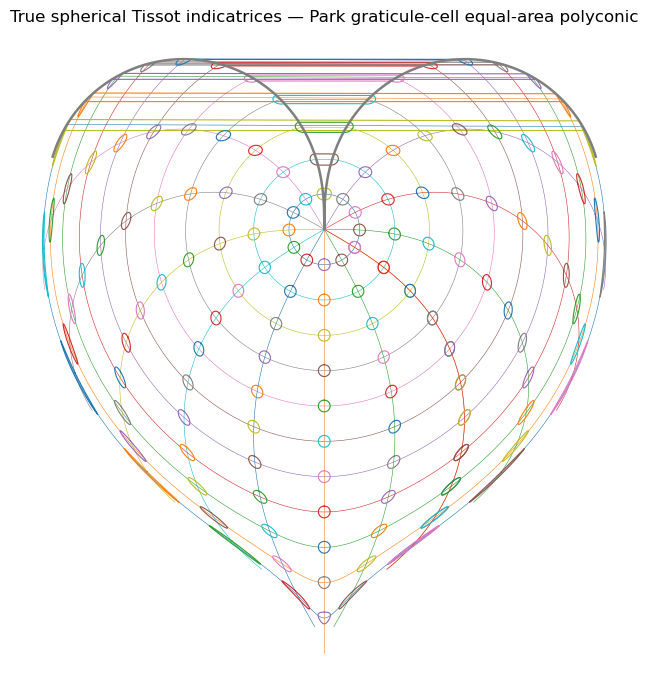

/mnt/data/park_equal_area_polyconic_true_tissot.png
/mnt/data/park_equal_area_polyconic_true_tissot.pdf


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Build equal-area projection grid
# -----------------------------
def signed_tri_area(A, B, C):
    return 0.5 * np.cross(B - A, C - A)

def cell_area_sphere_scaled(lat_north, lat_south, dlon_deg=0.5):
    cap_factor = 1.0 - np.sin(np.deg2rad(89.0))
    K = 1.0 / (2.0 * cap_factor)

    dlon = np.deg2rad(dlon_deg)
    return K * dlon * (
        np.sin(np.deg2rad(lat_north)) - np.sin(np.deg2rad(lat_south))
    )

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

# North pole
X[0, :] = 0.0
Y[0, :] = 90.0

# Central meridian
for A in range(181):
    X[A, 0] = 0.0
    Y[A, 0] = 90.0 - A

# First row below the pole
for A in range(361):
    lon = A / 2.0
    theta = np.deg2rad(lon)
    X[1, A] = np.sin(theta)
    Y[1, A] = 90.0 - np.cos(theta)

bad_cells = []

for a in range(1, 180):
    lat_north = 90.0 - a
    lat_south = 90.0 - (a + 1)

    target_area = cell_area_sphere_scaled(
        lat_north, lat_south, dlon_deg=0.5
    )

    target_signed_area = -target_area

    for b in range(360):
        A = np.array([X[a, b],     Y[a, b]])
        B = np.array([X[a, b + 1], Y[a, b + 1]])
        C = np.array([X[a + 1, b], Y[a + 1, b]])

        v = C - B
        L = np.hypot(v[0], v[1])

        if L == 0:
            bad_cells.append((a, b, "zero diagonal"))
            X[a + 1, b + 1] = X[a + 1, b]
            Y[a + 1, b + 1] = Y[a + 1, b]
            continue

        area_ABC = signed_tri_area(A, B, C)
        desired_cross = 2.0 * (target_signed_area - area_ABC)

        sin_theta = -desired_cross / L

        if abs(sin_theta) > 1.0:
            bad_cells.append((a, b, sin_theta))
            sin_theta = np.clip(sin_theta, -1.0, 1.0)

        cos_theta = np.sqrt(max(0.0, 1.0 - sin_theta**2))

        dx, dy = v

        ux = (cos_theta * dx - sin_theta * dy) / L
        uy = (sin_theta * dx + cos_theta * dy) / L

        D = B + np.array([ux, uy])

        X[a + 1, b + 1] = D[0]
        Y[a + 1, b + 1] = D[1]

Xp = X[:, :361]
Yp = Y[:, :361]

print("bad_cells:", len(bad_cells))
if bad_cells:
    print("first few:", bad_cells[:10])

CENTRAL_MERIDIAN = 120.0

def wrap_lon_relative(lon, lon0=CENTRAL_MERIDIAN):
    return ((lon - lon0 + 180.0) % 360.0) - 180.0

def project_point(lon, lat, lon0=CENTRAL_MERIDIAN):
    lon_rel = wrap_lon_relative(lon, lon0)
    lat = np.clip(lat, -90.0, 90.0)

    row = 90.0 - lat
    col = abs(lon_rel) * 2.0

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )

    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon_rel < 0:
        x = -x

    return x, y

# -----------------------------
# 2) True spherical small circles
# -----------------------------
def spherical_small_circle(lon0_deg, lat0_deg, radius_deg=3.0, n=180):
    lon0 = np.deg2rad(lon0_deg)
    lat0 = np.deg2rad(lat0_deg)
    r = np.deg2rad(radius_deg)

    pts = []
    thetas = np.linspace(0, 2 * np.pi, n, endpoint=True)

    sin_lat0 = np.sin(lat0)
    cos_lat0 = np.cos(lat0)
    sin_r = np.sin(r)
    cos_r = np.cos(r)

    for theta in thetas:
        lat = np.arcsin(
            sin_lat0 * cos_r
            + cos_lat0 * sin_r * np.cos(theta)
        )

        lon = lon0 + np.arctan2(
            np.sin(theta) * sin_r * cos_lat0,
            cos_r - sin_lat0 * np.sin(lat)
        )

        pts.append((np.rad2deg(lon), np.rad2deg(lat)))

    return pts

def projected_tissot(lon0, lat0, radius_deg=3.0, n=180):
    sph = spherical_small_circle(
        lon0,
        lat0,
        radius_deg=radius_deg,
        n=n
    )

    arr = np.array([
        project_point(lon, lat, CENTRAL_MERIDIAN)
        for lon, lat in sph
    ])

    return arr

# -----------------------------
# 3) Boundary
# -----------------------------
boundary_x = np.concatenate([-Xp[::-1, 360], Xp[:, 360]])
boundary_y = np.concatenate([Yp[::-1, 360], Yp[:, 360]])

# -----------------------------
# 4) Plot true Tissot indicatrices
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 10))

# Graticule lines
for lat in range(-75, 76, 15):
    lons = np.linspace(-180, 180, 721)
    pts = np.array([
        project_point(lon, lat, CENTRAL_MERIDIAN)
        for lon in lons
    ])
    ax.plot(pts[:, 0], pts[:, 1], linewidth=0.4)

for lon in range(-180, 181, 30):
    lats = np.linspace(-90, 90, 721)
    pts = np.array([
        project_point(lon, lat, CENTRAL_MERIDIAN)
        for lat in lats
    ])
    ax.plot(pts[:, 0], pts[:, 1], linewidth=0.4)

# True spherical Tissot indicatrices
for lat in range(-75, 76, 15):
    for lon in range(-180, 181, 30):
        ell = projected_tissot(
            lon,
            lat,
            radius_deg=2.5,
            n=160
        )
        ax.plot(ell[:, 0], ell[:, 1], linewidth=0.8)

# Boundary
ax.plot(boundary_x, boundary_y, linewidth=1.8)

ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    "True spherical Tissot indicatrices — "
    "Park graticule-cell equal-area polyconic"
)

png = "/mnt/data/park_equal_area_polyconic_true_tissot.png"
pdf = "/mnt/data/park_equal_area_polyconic_true_tissot.pdf"

plt.savefig(png, dpi=240, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print(png)
print(pdf)

# Longitude-Based Area Equalization

Given a map projection $X$, an equal-area version of the projection can be constructed by appropriately compressing the longitude coordinate while preserving the central meridian and all parallels.

More precisely, let a transformation on the sphere be defined that preserves latitude while modifying longitude according to a suitable function. The original projection $X$ is then applied to the transformed coordinates. The longitude transformation is chosen so that the resulting projection satisfies the equal-area condition.

In other words, the problem is to find a longitude remapping

$\lambda \mapsto \lambda'(\phi,\lambda)$

that leaves latitude unchanged,

$\phi' = \phi,$

and, after applying projection $X$ to $(\lambda',\phi)$, produces a final equal-area map projection.

This procedure may be viewed as a general framework for constructing equal-area variants of existing projections through longitude adjustment alone, while preserving the original structure of parallels and the central meridian.
  central meridian.
 

## Equal-Area Polyconic Projection

Applying Longitude-Based Area Equalization to the American Polyconic Projection yields an equal-area variant of the projection.

The method preserves latitude and the characteristic meridional structure of the original projection, while longitude is adjusted as a function of latitude to satisfy the equal-area condition.

This construction appears to be identical, or nearly identical, to:

**Maurer No. 179 — Polyconic; Equal-area (Hans Maurer, 1935).**

Accordingly, the present derivation may be regarded as an independent re-derivation of Maurer's equal-area polyconic projection.

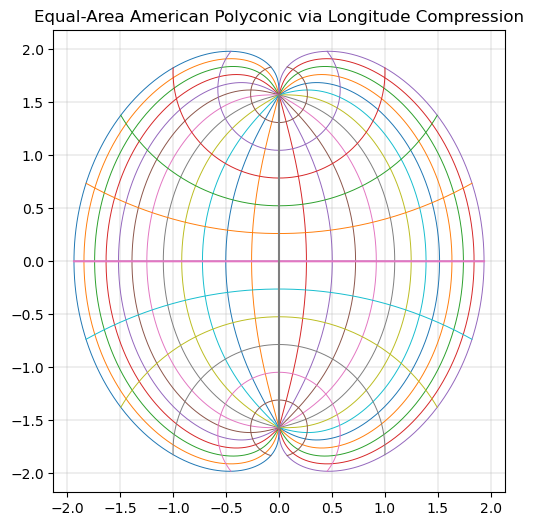

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def solve_t_equal_area_polyconic(phi, lam, max_iter=30, tol=1e-13):
    """
    Solve:
        t - cos(phi)^2 sin(t) = lam * sin(phi)^3
    where t = mu * sin(phi).
    """
    s = np.sin(phi)
    c2 = np.cos(phi) ** 2

    rhs = lam * s**3

    # Good initial guess
    t = rhs / np.maximum(1 - c2, 1e-12)

    # Safer fallback near equator: lam = mu + mu^3/6
    near_eq = np.abs(s) < 1e-6
    if np.any(near_eq):
        t = np.where(near_eq, lam * s, t)

    for _ in range(max_iter):
        f = t - c2 * np.sin(t) - rhs
        fp = 1 - c2 * np.cos(t)

        step = f / fp
        t_new = t - step

        if np.nanmax(np.abs(step)) < tol:
            t = t_new
            break

        t = t_new

    return t


def equal_area_american_polyconic(lon, lat, lon0=0.0):
    """
    Equal-area longitude-compressed American Polyconic.

    Parameters
    ----------
    lon, lat : radians
    lon0 : central meridian, radians

    Returns
    -------
    x, y
    """
    lam = lon - lon0
    phi = lat

    s = np.sin(phi)
    c = np.cos(phi)

    x = np.empty_like(phi, dtype=float)
    y = np.empty_like(phi, dtype=float)

    near_eq = np.abs(phi) < 1e-8

    # Equator limit:
    # lambda = mu + mu^3/6
    # x = mu, y = 0
    if np.any(near_eq):
        mu = solve_mu_equator(lam[near_eq])
        x[near_eq] = mu
        y[near_eq] = 0.0

    if np.any(~near_eq):
        ph = phi[~near_eq]
        la = lam[~near_eq]

        s = np.sin(ph)
        t = solve_t_equal_area_polyconic(ph, la)
        mu = t / s

        cot = 1 / np.tan(ph)

        x[~near_eq] = cot * np.sin(t)
        y[~near_eq] = ph + cot * (1 - np.cos(t))

    return x, y


def solve_mu_equator(lam, max_iter=30, tol=1e-13):
    """
    Solve equator equation:
        lam = mu + mu^3 / 6
    """
    mu = lam.copy().astype(float)

    for _ in range(max_iter):
        f = mu + mu**3 / 6 - lam
        fp = 1 + mu**2 / 2
        step = f / fp
        mu_new = mu - step

        if np.nanmax(np.abs(step)) < tol:
            mu = mu_new
            break

        mu = mu_new

    return mu


def plot_graticule():
    fig, ax = plt.subplots(figsize=(12, 6))

    # Meridians
    for lon_deg in range(-180, 181, 15):
        lat_deg = np.linspace(-89.9, 89.9, 800)
        lon_deg_arr = np.full_like(lat_deg, lon_deg)

        lon = np.deg2rad(lon_deg_arr)
        lat = np.deg2rad(lat_deg)

        x, y = equal_area_american_polyconic(lon, lat)
        ax.plot(x, y, linewidth=0.7)

    # Parallels
    for lat_deg in range(-75, 76, 15):
        lon_deg = np.linspace(-180, 180, 1200)
        lat_deg_arr = np.full_like(lon_deg, lat_deg)

        lon = np.deg2rad(lon_deg)
        lat = np.deg2rad(lat_deg_arr)

        x, y = equal_area_american_polyconic(lon, lat)
        ax.plot(x, y, linewidth=0.7)

    # Equator and central meridian
    lon_deg = np.linspace(-180, 180, 1200)
    lat_deg = np.zeros_like(lon_deg)
    x, y = equal_area_american_polyconic(np.deg2rad(lon_deg), np.deg2rad(lat_deg))
    ax.plot(x, y, linewidth=1.5)

    lat_deg = np.linspace(-89.9, 89.9, 800)
    lon_deg = np.zeros_like(lat_deg)
    x, y = equal_area_american_polyconic(np.deg2rad(lon_deg), np.deg2rad(lat_deg))
    ax.plot(x, y, linewidth=1.5)

    ax.set_aspect("equal")
    ax.set_title("Equal-Area American Polyconic via Longitude Compression")
    ax.grid(True, linewidth=0.3)
    plt.show()


plot_graticule()

## Longitude Compression Applied to a Transverse Stereographic Projection

The Longitude-Based Area Equalization principle used for the equal-area polyconic projection was also applied to a transverse stereographic projection.

The projection preserves distances along the original meridian direction while modifying the transverse coordinate to satisfy the equal-area condition.

To the author's knowledge, no identical projection has yet been identified in the literature.

Whether this projection is genuinely new or an independent rediscovery of a previously published projection remains to be determined through further literature review.

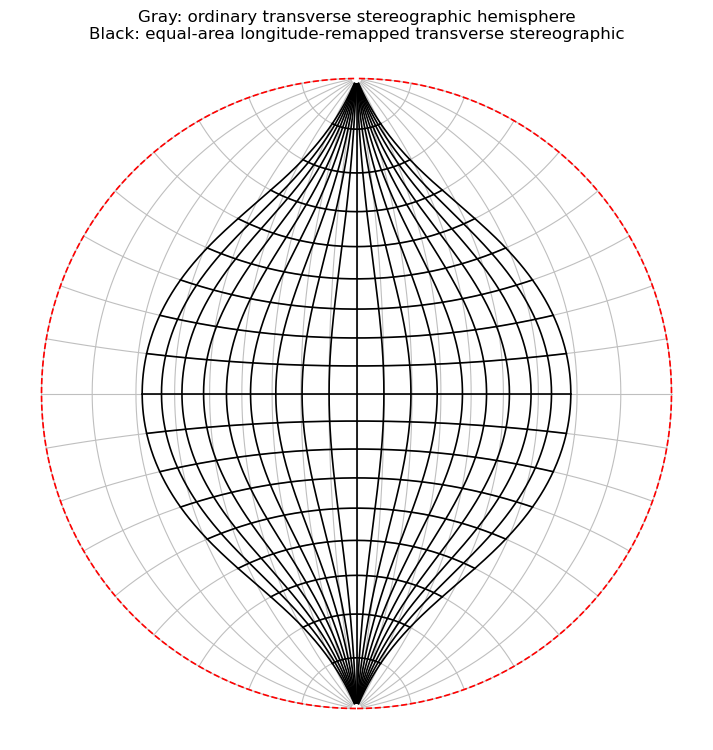

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Transverse stereographic
# -----------------------------

def trans_stereo(lam, phi):
    D = 1 + np.cos(phi) * np.cos(lam)
    x = 2 * np.cos(phi) * np.sin(lam) / D
    y = 2 * np.sin(phi) / D
    return x, y


# -----------------------------
# Equal-area longitude remapping
# d lambda' / d lambda = (1 + cos(phi) cos(lambda'))^2 / 4
# -----------------------------

def F_lamp(lamp, phi):
    u = np.linspace(0, lamp, 800)
    a = np.cos(phi)
    return np.trapz(4 / (1 + a*np.cos(u))**2, u)


def solve_lamp(lam, phi):
    sign = np.sign(lam)
    target = abs(lam)

    if target == 0:
        return 0.0

    lo, hi = 0.0, np.pi - 1e-8

    for _ in range(70):
        mid = 0.5 * (lo + hi)
        if F_lamp(mid, phi) < target:
            lo = mid
        else:
            hi = mid

    return sign * 0.5 * (lo + hi)


def remap_lam_array(lam_arr, phi_arr):
    out = np.empty_like(lam_arr, dtype=float)
    for i, (lam, phi) in enumerate(zip(lam_arr, phi_arr)):
        out[i] = solve_lamp(lam, phi)
    return out


# -----------------------------
# Plot
# -----------------------------

fig, ax = plt.subplots(figsize=(9, 9))

# 1) ordinary transverse stereographic graticule, hemisphere only
for lat in range(-80, 81, 10):
    phi = np.deg2rad(lat)
    lam = np.deg2rad(np.linspace(-90, 90, 500))
    x, y = trans_stereo(lam, phi)
    ax.plot(x, y, color="0.75", linewidth=0.8)

for lon in range(-90, 91, 10):
    lam = np.deg2rad(lon)
    phi = np.deg2rad(np.linspace(-89, 89, 500))
    x, y = trans_stereo(lam, phi)
    ax.plot(x, y, color="0.75", linewidth=0.8)


# 2) equal-area remapped graticule, source hemisphere only
for lat in range(-80, 81, 10):
    phi = np.full(500, np.deg2rad(lat))
    lam = np.deg2rad(np.linspace(-90, 90, 500))

    lamp = remap_lam_array(lam, phi)
    x, y = trans_stereo(lamp, phi)

    ax.plot(x, y, color="black", linewidth=1.2)

for lon in range(-90, 91, 10):
    lam = np.full(500, np.deg2rad(lon))
    phi = np.deg2rad(np.linspace(-89, 89, 500))

    lamp = remap_lam_array(lam, phi)
    x, y = trans_stereo(lamp, phi)

    ax.plot(x, y, color="black", linewidth=1.2)


# 3) original hemisphere boundary
phi = np.deg2rad(np.linspace(-89.9, 89.9, 800))

for lon in [-90, 90]:
    lam = np.deg2rad(lon)
    x, y = trans_stereo(lam, phi)
    ax.plot(x, y, "r--", linewidth=1.2)


ax.set_aspect("equal", adjustable="box")
ax.set_axis_off()
ax.set_title("Gray: ordinary transverse stereographic hemisphere\nBlack: equal-area longitude-remapped transverse stereographic")

plt.show()

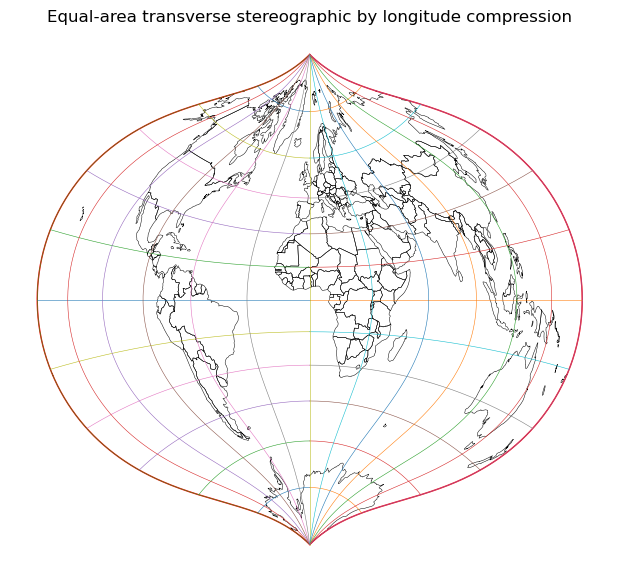

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString

# -----------------------------
# 1) Transverse equal-area-by-longitude-compression
# -----------------------------

def F_of_lamp(lamp, phi):
    """
    lambda = integral_0^lambda' 4 / (1 + cos(phi) cos(u))^2 du
    numerical integral by cumulative trapezoid
    """
    a = np.cos(phi)
    n = 600
    u = np.linspace(0, lamp, n)
    integrand = 4.0 / (1.0 + a * np.cos(u))**2
    return np.trapz(integrand, u)


def solve_lamp(lam, phi):
    """
    Solve F(lambda') = lambda.
    Odd symmetry is used.
    """
    sign = np.sign(lam)
    target = abs(lam)

    if target == 0:
        return 0.0

    # lambda' stays inside (-pi, pi)
    lo, hi = 0.0, np.pi - 1e-9

    # shrink hi if F(hi) is too large; usually enough
    for _ in range(80):
        mid = 0.5 * (lo + hi)
        val = F_of_lamp(mid, phi)

        if val < target:
            lo = mid
        else:
            hi = mid

    return sign * 0.5 * (lo + hi)

def wrap_pi_keep_endpoint(lam):
    out = (lam + np.pi) % (2*np.pi) - np.pi
    if np.isclose(out, -np.pi) and lam > 0:
        out = np.pi
    return out

def project_point(lon_deg, lat_deg, lon0_deg=0):
    lam_raw = np.deg2rad(lon_deg - lon0_deg)
    phi = np.deg2rad(lat_deg)

    lam = wrap_pi_keep_endpoint(lam_raw)

    lamp = solve_lamp(lam, phi)

    D = 1.0 + np.cos(phi) * np.cos(lamp)

    x = 2.0 * np.cos(phi) * np.sin(lamp) / D
    y = 2.0 * np.sin(phi) / D

    return x, y


def project_array(lon, lat, lon0_deg=0):
    lon = np.asarray(lon)
    lat = np.asarray(lat)

    x = np.empty_like(lon, dtype=float)
    y = np.empty_like(lat, dtype=float)

    for i in range(len(lon)):
        x[i], y[i] = project_point(lon[i], lat[i], lon0_deg)

    return x, y


# -----------------------------
# 2) Densify geometry
# -----------------------------

def densify_coords(coords, step=1.0):
    out = []

    coords = list(coords)

    for (lon1, lat1), (lon2, lat2) in zip(coords[:-1], coords[1:]):

        dlon = lon2 - lon1

        # avoid drawing across antimeridian directly
        if abs(dlon) > 180:
            out.append((lon1, lat1))
            continue

        dlat = lat2 - lat1
        n = max(1, int(max(abs(dlon), abs(dlat)) / step))

        for j in range(n):
            t = j / n
            out.append((lon1 + t*dlon, lat1 + t*dlat))

    out.append(coords[-1])
    return out


def project_ring(coords, lon0_deg=0):
    coords = densify_coords(coords, step=0.5)

    lon = np.array([p[0] for p in coords])
    lat = np.array([p[1] for p in coords])

    x, y = project_array(lon, lat, lon0_deg)

    mask = np.isfinite(x) & np.isfinite(y)
    return np.column_stack([x[mask], y[mask]])


def plot_geom(ax, geom, lon0_deg=0):
    if geom.is_empty:
        return

    if isinstance(geom, Polygon):
        xy = project_ring(geom.exterior.coords, lon0_deg)
        if len(xy) >= 2:
            ax.plot(
                xy[:,0], xy[:,1],
                color="black",
                linewidth=0.35
            )

    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            plot_geom(ax, g, lon0_deg)

# -----------------------------
# 3) Load and plot
# -----------------------------

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

fig, ax = plt.subplots(figsize=(11, 7))

for geom in world.geometry:
    plot_geom(ax, geom, lon0_deg=0)


lats = np.linspace(-90, 90, 721)

for lon in [-180, 180]:
    lons = np.full_like(lats, lon)
    x, y = project_array(lons, lats)
    ax.plot(x, y, color="red", linewidth=1.0)

# parallels
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 361)
        lats = np.full_like(lons, lat)
        x, y = project_array(lons, lats)
        ax.plot(x, y, linewidth=0.4)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-90, 90, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array(lons, lats)
    ax.plot(x, y, linewidth=0.4)
ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title("Equal-area transverse stereographic by longitude compression")

plt.show()

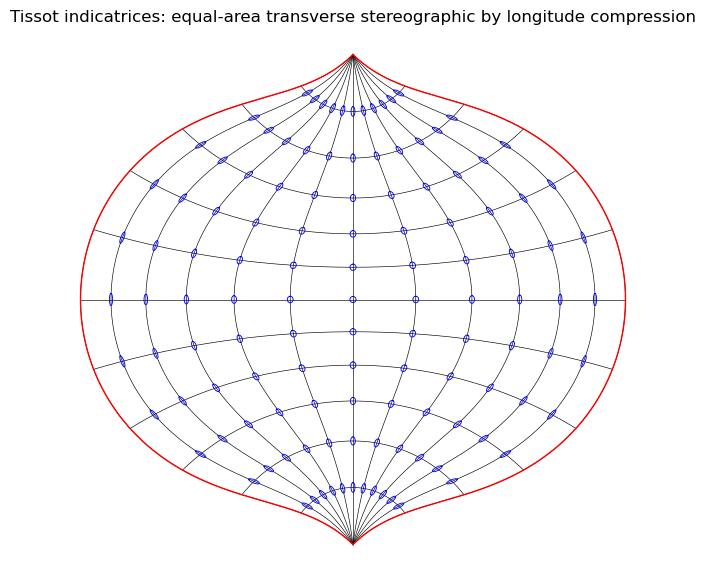

In [39]:
# -----------------------------
# 3) Grid + Tissot ellipses only
# -----------------------------

def jacobian_numeric(lon_deg, lat_deg, h=1e-5):
    # input basis: (lambda, phi) in radians
    d = np.rad2deg(h)

    x1, y1 = project_point(lon_deg + d, lat_deg)
    x2, y2 = project_point(lon_deg - d, lat_deg)
    dx_dlam = (x1 - x2) / (2*h)
    dy_dlam = (y1 - y2) / (2*h)

    x1, y1 = project_point(lon_deg, lat_deg + d)
    x2, y2 = project_point(lon_deg, lat_deg - d)
    dx_dphi = (x1 - x2) / (2*h)
    dy_dphi = (y1 - y2) / (2*h)

    return np.array([[dx_dlam, dx_dphi],
                     [dy_dlam, dy_dphi]])


def tissot_axes(lon_deg, lat_deg):
    phi = np.deg2rad(lat_deg)
    J = jacobian_numeric(lon_deg, lat_deg)

    # orthonormal sphere basis:
    # east unit distance = cos(phi) dλ, north unit distance = dφ
    C = np.array([[1 / max(np.cos(phi), 1e-12), 0],
                  [0, 1]])

    A = J @ C

    U, s, Vt = np.linalg.svd(A)
    return U, s


def draw_tissot(ax, lon_deg, lat_deg, r=0.035, n=80, **kwargs):
    U, s = tissot_axes(lon_deg, lat_deg)

    theta = np.linspace(0, 2*np.pi, n)
    circle = np.vstack([np.cos(theta), np.sin(theta)])

    ellipse = U @ np.diag(s) @ circle
    x0, y0 = project_point(lon_deg, lat_deg)

    ax.plot(
        x0 + r * ellipse[0],
        y0 + r * ellipse[1],
        **kwargs
    )
def draw_polar_tissot(ax, pole_lat=90, r_sph_deg=0.6, scale=0.04, n=144, **kwargs):
    """
    극점의 티소: 극 주변의 작은 구면원(lat = 90-r 또는 -90+r)을
    방위각 전체에 대해 투영한 뒤, 극점 기준으로 축소해서 그림.
    """
    if pole_lat > 0:
        lats = np.full(n, 90.0 - r_sph_deg)
        lons = np.linspace(-180, 180, n)
        x0, y0 = project_point(0, 90)
    else:
        lats = np.full(n, -90.0 + r_sph_deg)
        lons = np.linspace(-180, 180, n)
        x0, y0 = project_point(0, -90)

    x, y = project_array(lons, lats)

    # 실제 극 주변 상의 상대 모양만 사용
    dx = x - x0
    dy = y - y0

    # 보기 좋은 크기로 정규화
    norm = np.sqrt(dx*dx + dy*dy)
    m = np.nanmax(norm)

    ax.plot(
        x0 + scale * dx / m,
        y0 + scale * dy / m,
        **kwargs
    )

fig, ax = plt.subplots(figsize=(11, 7))

# parallels
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 721)
        lats = np.full_like(lons, lat)
        x, y = project_array(lons, lats)
        ax.plot(x, y, color="black", linewidth=0.45)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-90, 90, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array(lons, lats)
    ax.plot(x, y, color="black", linewidth=0.45)

# boundary
for lon in [-180, 180]:
    lats = np.linspace(-90, 90, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array(lons, lats)
    ax.plot(x, y, color="red", linewidth=1.0)

# Tissot ellipses
for lat in [-75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75]:
    for lon in range(-150, 151, 30):
        draw_tissot(
            ax, lon, lat,
            r=0.025,
            n=96,
            color="blue",
            linewidth=0.65
        )

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title("Tissot indicatrices: equal-area transverse stereographic by longitude compression")

plt.show()

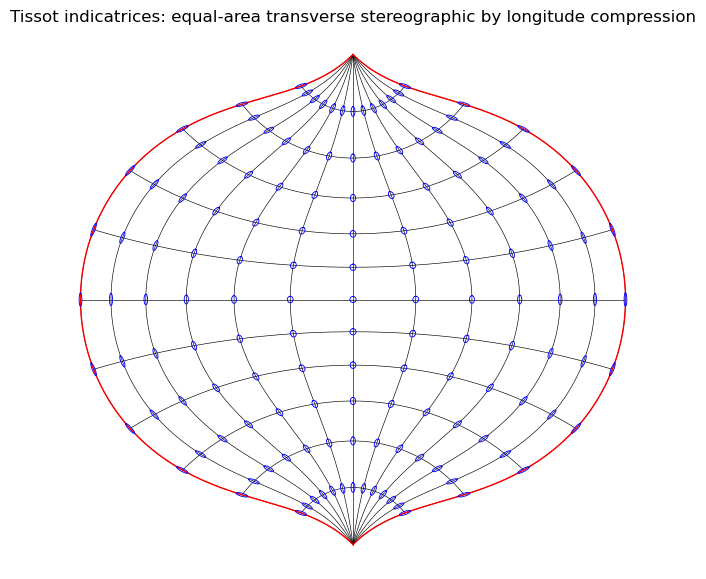

In [41]:
# -----------------------------
# 3) Grid + Tissot ellipses only
# -----------------------------

def jacobian_numeric(lon_deg, lat_deg, h=1e-5):
    d = np.rad2deg(h)

    # 경도 방향: seam에서는 한쪽 미분
    if np.isclose(abs(lon_deg), 180.0):
        if lon_deg > 0:
            x0, y0 = project_point(lon_deg, lat_deg)
            x1, y1 = project_point(lon_deg - d, lat_deg)
            dx_dlam = (x0 - x1) / h
            dy_dlam = (y0 - y1) / h
        else:
            x1, y1 = project_point(lon_deg + d, lat_deg)
            x0, y0 = project_point(lon_deg, lat_deg)
            dx_dlam = (x1 - x0) / h
            dy_dlam = (y1 - y0) / h
    else:
        x1, y1 = project_point(lon_deg + d, lat_deg)
        x2, y2 = project_point(lon_deg - d, lat_deg)
        dx_dlam = (x1 - x2) / (2*h)
        dy_dlam = (y1 - y2) / (2*h)

    # 위도 방향은 그대로 중앙차분
    x1, y1 = project_point(lon_deg, lat_deg + d)
    x2, y2 = project_point(lon_deg, lat_deg - d)
    dx_dphi = (x1 - x2) / (2*h)
    dy_dphi = (y1 - y2) / (2*h)

    return np.array([[dx_dlam, dx_dphi],
                     [dy_dlam, dy_dphi]])

def tissot_axes(lon_deg, lat_deg):
    phi = np.deg2rad(lat_deg)
    J = jacobian_numeric(lon_deg, lat_deg)

    # orthonormal sphere basis:
    # east unit distance = cos(phi) dλ, north unit distance = dφ
    C = np.array([[1 / max(np.cos(phi), 1e-12), 0],
                  [0, 1]])

    A = J @ C

    U, s, Vt = np.linalg.svd(A)
    return U, s


def draw_tissot(ax, lon_deg, lat_deg, r=0.035, n=80, **kwargs):
    U, s = tissot_axes(lon_deg, lat_deg)

    theta = np.linspace(0, 2*np.pi, n)
    circle = np.vstack([np.cos(theta), np.sin(theta)])

    ellipse = U @ np.diag(s) @ circle
    x0, y0 = project_point(lon_deg, lat_deg)

    ax.plot(
        x0 + r * ellipse[0],
        y0 + r * ellipse[1],
        **kwargs
    )
def draw_polar_tissot(ax, pole_lat=90, r_sph_deg=0.6, scale=0.04, n=144, **kwargs):
    """
    극점의 티소: 극 주변의 작은 구면원(lat = 90-r 또는 -90+r)을
    방위각 전체에 대해 투영한 뒤, 극점 기준으로 축소해서 그림.
    """
    if pole_lat > 0:
        lats = np.full(n, 90.0 - r_sph_deg)
        lons = np.linspace(-180, 180, n)
        x0, y0 = project_point(0, 90)
    else:
        lats = np.full(n, -90.0 + r_sph_deg)
        lons = np.linspace(-180, 180, n)
        x0, y0 = project_point(0, -90)

    x, y = project_array(lons, lats)

    # 실제 극 주변 상의 상대 모양만 사용
    dx = x - x0
    dy = y - y0

    # 보기 좋은 크기로 정규화
    norm = np.sqrt(dx*dx + dy*dy)
    m = np.nanmax(norm)

    ax.plot(
        x0 + scale * dx / m,
        y0 + scale * dy / m,
        **kwargs
    )

fig, ax = plt.subplots(figsize=(11, 7))

# parallels
for lat in range(-75, 76, 15):
    for lo, hi in [(-180, 0), (0, 180)]:
        lons = np.linspace(lo, hi, 721)
        lats = np.full_like(lons, lat)
        x, y = project_array(lons, lats)
        ax.plot(x, y, color="black", linewidth=0.45)

# meridians
for lon in range(-180, 181, 30):
    lats = np.linspace(-90, 90, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array(lons, lats)
    ax.plot(x, y, color="black", linewidth=0.45)

# boundary
for lon in [-180, 180]:
    lats = np.linspace(-90, 90, 721)
    lons = np.full_like(lats, lon)
    x, y = project_array(lons, lats)
    ax.plot(x, y, color="red", linewidth=1.0)

# Tissot ellipses
for lat in [-75, -60, -45, -30, -15, 0, 15, 30, 45, 60, 75]:
    for lon in range(-180, 181, 30):
        draw_tissot(
            ax, lon, lat,
            r=0.025,
            n=96,
            color="blue",
            linewidth=0.65
        )

ax.set_aspect("equal", adjustable="box")
ax.autoscale()
ax.set_axis_off()
ax.set_title("Tissot indicatrices: equal-area transverse stereographic by longitude compression")

plt.show()